# MTH6161 Mini-Project: CNN from Scratch for MNIST

In this notebook, I implement a Convolutional Neural Network from scratch for MNIST digit classification. The model itself does not use PyTorch, TensorFlow or any other deep-learning framework. `torchvision.datasets` is only used to download MNIST before converting the data into NumPy arrays.

The aim is to understand how the main parts of a CNN work together, including convolution, ReLU, max pooling, flattening, softmax, cross-entropy loss, manual backpropagation and gradient checking.

## Model Structure

```text
Input    : 1 × 28 × 28

Conv1    : 8 filters, 3×3, stride 1, no padding  →  8 × 26 × 26
ReLU
MaxPool  : 2×2, stride 2                         →  8 × 13 × 13

Conv2    : 16 filters, 3×3, stride 1, no padding →  16 × 11 × 11
ReLU
MaxPool  : 2×2, stride 2                         →  16 × 5 × 5

Flatten  : 16 × 5 × 5 = 400
FC       : 400 → 10
Softmax
Loss     : cross-entropy

## 1. Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time


## 2. Load MNIST

This section i loaded the MNIST dataset using `torchvision`, then converted the images and labels into NumPy arrays so the CNN model itself is implemented without PyTorch.

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


train images: (60000, 28, 28)  labels: (60000,)
test  images: (10000, 28, 28)  labels: (10000,)


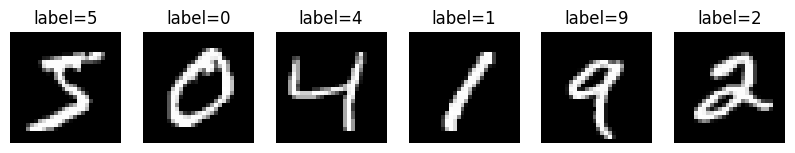

In [ ]:
from torchvision import datasets, transforms

transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Convert to numpy and normalise to [0,1]
Xtr = train_dataset.data.numpy().astype(np.float32) / 255.0   # (60000,28,28)
Ytr = train_dataset.targets.numpy()
Xte = test_dataset.data.numpy().astype(np.float32) / 255.0    # (10000,28,28)
Yte = test_dataset.targets.numpy()

print('train images:', Xtr.shape, ' labels:', Ytr.shape)
print('test  images:', Xte.shape, ' labels:', Yte.shape)

# Show a few examples
fig, ax = plt.subplots(1, 6, figsize=(10, 2))
for i in range(6):
    ax[i].imshow(Xtr[i], cmap='gray')
    ax[i].set_title(f'label={Ytr[i]}')
    ax[i].axis('off')
plt.show()


## 3. Activation, softmax, and cross-entropy




In [ ]:
def ReLU(x):
    return np.maximum(0.0, x)

def softmax(x):
    # subtract max for numerical stability
    m = np.max(x)
    e = np.exp(x - m)
    return e / np.sum(e)

def cross_entropy(y_pred, y_true):
    # y_true is a one-hot vector (length 10)
    eps = 1e-12
    return -float(np.dot(np.log(y_pred + eps), y_true))


## 4. The Convolution Layer

Here I implement the convolution layer using `im2col`. This lets me turn the small image patches into columns, so the convolution can be done more efficiently with matrix multiplication. I also include `col2im`, which is used later to put the gradients back into the correct image shape during backpropagation.


In [ ]:
def im2col(x, kH, kW, stride=1):
    """
    x   : (C, H, W)
    out : (C*kH*kW, oH*oW)  -- each column is one receptive field
    """
    C, H, W = x.shape
    oH = (H - kH) // stride + 1
    oW = (W - kW) // stride + 1
    cols = np.zeros((C * kH * kW, oH * oW), dtype=x.dtype)
    col = 0
    for i in range(oH):
        for j in range(oW):
            patch = x[:, i*stride:i*stride+kH, j*stride:j*stride+kW]
            cols[:, col] = patch.reshape(-1)
            col += 1
    return cols, oH, oW

def col2im(cols, C, H, W, kH, kW, stride=1):
    """Inverse of im2col: scatter-add columns back into an image of shape (C,H,W)."""
    oH = (H - kH) // stride + 1
    oW = (W - kW) // stride + 1
    x = np.zeros((C, H, W), dtype=cols.dtype)
    col = 0
    for i in range(oH):
        for j in range(oW):
            patch = cols[:, col].reshape(C, kH, kW)
            x[:, i*stride:i*stride+kH, j*stride:j*stride+kW] += patch
            col += 1
    return x


### Forward pass of a convolution layer

Here I use `im2col` to make the convolution easier to compute. The image patches are rearranged into a matrix, and the filters are reshaped into rows, so the forward pass becomes a matrix multiplication:

$$
Y_{\text{flat}} = W_{\text{row}}X_{\text{col}} + b
$$


In [ ]:
def conv_forward(x, W, b):
    """
    x : (Cin, H, W)
    W : (Cout, Cin, kH, kW)
    b : (Cout,)
    returns y of shape (Cout, oH, oW), plus a cache for backward.
    """
    Cout, Cin, kH, kW = W.shape
    cols, oH, oW = im2col(x, kH, kW)
    Wrow = W.reshape(Cout, -1)
    y = Wrow @ cols + b[:, None]
    return y.reshape(Cout, oH, oW), (x.shape, cols, Wrow, kH, kW, oH, oW)


## 5. The Max-Pooling Layer

Here I implement $2 \times 2$ max pooling with stride 2. This reduces the size of the feature maps by keeping the largest value from each small window. I also store the position of the maximum value, because this is needed later when sending the gradient back during backpropagation.

In [ ]:
def maxpool_forward(x, k=2, stride=2):
    """
    x : (C, H, W)
    returns y of shape (C, oH, oW), plus a cache (argmax positions).
    """
    C, H, W = x.shape
    oH = (H - k) // stride + 1
    oW = (W - k) // stride + 1
    y   = np.zeros((C, oH, oW), dtype=x.dtype)
    idx = np.zeros((C, oH, oW, 2), dtype=np.int64)
    for c in range(C):
        for i in range(oH):
            for j in range(oW):
                win = x[c, i*stride:i*stride+k, j*stride:j*stride+k]
                a, b = np.unravel_index(np.argmax(win), win.shape)
                y[c, i, j] = win[a, b]
                idx[c, i, j, 0] = i*stride + a
                idx[c, i, j, 1] = j*stride + b
    return y, (x.shape, idx, k, stride)


## 6. Full Forward Pass

This section puts the layers together to make the full CNN forward pass. The model passes the image through convolution, ReLU, max pooling, flattening, the fully connected layer and softmax. I also store the intermediate values because they are needed later for backpropagation.

In [ ]:
def forward(image, params):
    """Run a single image through the network.  Returns prediction and cache."""
    W1, b1, W2, b2, W3, b3 = params

    a1, c_conv1 = conv_forward(image, W1, b1)   # (8,26,26)
    z1 = ReLU(a1)
    p1, c_pool1 = maxpool_forward(z1)            # (8,13,13)

    a2, c_conv2 = conv_forward(p1, W2, b2)       # (16,11,11)
    z2 = ReLU(a2)
    p2, c_pool2 = maxpool_forward(z2)            # (16, 5, 5)

    flat = p2.reshape(-1)                        # 400
    logits = W3 @ flat + b3                      # (10,)
    y = softmax(logits)

    cache = (image, c_conv1, a1, z1, c_pool1,
             c_conv2, a2, z2, c_pool2,
             flat, logits)
    return y, cache


## 7. Backpropagation and Parameter Updates

Here I implement the backward pass for the CNN. The gradients are passed back through the softmax, fully connected layer, ReLU, max pooling and convolution layers.

The convolution backward pass uses the same `im2col` idea from the forward pass, and `col2im` is used to reshape the gradients back into the correct feature-map shape.

After the gradients are calculated, the weights and biases are updated using gradient descent:

$$
\theta \leftarrow \theta - \eta \frac{\partial L}{\partial \theta}
$$

In [ ]:
def conv_backward(dY, cache, W):
    x_shape, cols, Wrow, kH, kW, oH, oW = cache
    Cout = W.shape[0]
    dy_flat = dY.reshape(Cout, -1)            # (Cout, oH*oW)
    dWrow = dy_flat @ cols.T                  # (Cout, Cin*kH*kW)
    dW    = dWrow.reshape(W.shape)
    db    = dy_flat.sum(axis=1)               # (Cout,)
    dcols = Wrow.T @ dy_flat                  # (Cin*kH*kW, oH*oW)
    Cin, H, Wd = x_shape
    dx    = col2im(dcols, Cin, H, Wd, kH, kW)
    return dx, dW, db

def maxpool_backward(dY, cache):
    x_shape, idx, k, stride = cache
    dx = np.zeros(x_shape, dtype=dY.dtype)
    C, oH, oW = dY.shape
    for c in range(C):
        for i in range(oH):
            for j in range(oW):
                ii, jj = idx[c, i, j]
                dx[c, ii, jj] += dY[c, i, j]
    return dx

def backward(y_pred, y_true, cache, params):
    W1, b1, W2, b2, W3, b3 = params
    (image, c_conv1, a1, z1, c_pool1,
     c_conv2, a2, z2, c_pool2,
     flat, logits) = cache

    # softmax + CE
    dlogits = y_pred - y_true                  # (10,)
    dW3 = np.outer(dlogits, flat)              # (10, 400)
    db3 = dlogits
    dflat = W3.T @ dlogits                     # (400,)

    # back through pool2 (shape (16,5,5))
    dp2 = dflat.reshape(c_pool2[1].shape[:3])
    dz2 = maxpool_backward(dp2, c_pool2)
    da2 = dz2 * (a2 > 0)                       # ReLU'
    dp1, dW2, db2 = conv_backward(da2, c_conv2, W2)

    dz1 = maxpool_backward(dp1, c_pool1)
    da1 = dz1 * (a1 > 0)
    _, dW1, db1 = conv_backward(da1, c_conv1, W1)

    return [dW1, db1, dW2, db2, dW3, db3]


## 8. Parameter Initialisation

Here I initialise the weights using He/Kaiming initialisation, which works well with ReLU layers. The weights are sampled with variance:

$$
\frac{2}{n_{\text{in}}}
$$

where $n_{\text{in}}$ is the number of inputs to the layer.

In [ ]:
def init_params(seed=1):
    g = np.random.default_rng(seed)
    W1 = g.standard_normal((8, 1, 3, 3))  * np.sqrt(2.0 / (1*3*3))
    b1 = np.zeros(8)
    W2 = g.standard_normal((16, 8, 3, 3)) * np.sqrt(2.0 / (8*3*3))
    b2 = np.zeros(16)
    W3 = g.standard_normal((10, 16*5*5))  * np.sqrt(2.0 / (16*5*5))
    b3 = np.zeros(10)
    return [W1, b1, W2, b2, W3, b3]


## 9. Numerical Gradient Check

Before training, I used a numerical gradient check to make sure the backward pass was working properly. This compares the gradients from backpropagation with a small numerical estimate:

$$
\frac{\partial L}{\partial \theta}
\approx
\frac{L(\theta+h)-L(\theta-h)}{2h}
$$

I only tested a few randomly selected parameters because checking every weight would be too slow. The small relative errors showed that the gradients were consistent.

In [ ]:
def grad_check():
    params = init_params(seed=42)
    rng = np.random.default_rng(0)
    image = rng.standard_normal((1, 28, 28))
    y_true = np.zeros(10); y_true[3] = 1.0

    y_pred, cache = forward(image, params)
    grads = backward(y_pred, y_true, cache, params)

    h = 1e-5
    tests = [("W1[0,0,1,1]", 0, (0,0,1,1)),
             ("W2[3,2,0,1]", 2, (3,2,0,1)),
             ("W3[2,5]",     4, (2,5)),
             ("b3[7]",       5, (7,))]
    print(f"{'parameter':14s} {'analytic':>14s} {'numerical':>14s} {'rel err':>10s}")
    print('-'*56)
    for name, pi, idx in tests:
        p = params[pi]; g = grads[pi]
        old = p[idx]
        p[idx] = old + h
        L_plus,  _ = forward(image, params); L_plus  = cross_entropy(L_plus,  y_true)
        p[idx] = old - h
        L_minus, _ = forward(image, params); L_minus = cross_entropy(L_minus, y_true)
        p[idx] = old
        num = (L_plus - L_minus) / (2*h)
        ana = g[idx]
        rel = abs(num - ana) / (abs(num) + abs(ana) + 1e-12)
        print(f"{name:14s} {ana:>+14.6e} {num:>+14.6e} {rel:>10.2e}")

grad_check()


parameter            analytic      numerical    rel err
--------------------------------------------------------
W1[0,0,1,1]     -1.989201e-01  -1.989201e-01   8.02e-11
W2[3,2,0,1]     +1.572539e-01  +1.572539e-01   6.32e-11
W3[2,5]         +0.000000e+00  +0.000000e+00   0.00e+00
b3[7]           +1.925576e-02  +1.925576e-02   3.32e-10


## 10. Training

Here I train the model using mini-batch stochastic gradient descent. Since the CNN is written from scratch in NumPy and runs on the CPU, I used a small batch size and a limited number of training steps.

In my final run, the model was trained with `N_STEPS = 3000`, `BATCH = 8` and `lr = 0.01`. This gave a final test accuracy of **95.23%**.

In [ ]:
# Training hyperparameters
N_STEPS = 3000
BATCH   = 8
lr      = 0.01

params = init_params(seed=7)
rng    = np.random.default_rng(123)

loss_history = []
t0 = time.time()
running = 0.0
for step in range(N_STEPS):
    idx_batch = rng.choice(Xtr.shape[0], BATCH, replace=False)
    grads_sum = None
    loss_sum  = 0.0
    for k in idx_batch:
        image  = Xtr[k][None, :, :]                  # (1,28,28)
        y_true = np.zeros(10); y_true[Ytr[k]] = 1.0
        y_pred, cache = forward(image, params)
        loss_sum += cross_entropy(y_pred, y_true)
        g = backward(y_pred, y_true, cache, params)
        if grads_sum is None:
            grads_sum = g
        else:
            for i in range(len(g)):
                grads_sum[i] = grads_sum[i] + g[i]
    # SGD update with average gradient over the mini-batch
    for i in range(len(params)):
        params[i] -= lr * grads_sum[i] / BATCH

    running += loss_sum / BATCH
    if (step + 1) % 100 == 0:
        avg = running / 100
        loss_history.append(avg)
        running = 0.0
        print(f"step {step+1:5d}/{N_STEPS}  avg loss = {avg:.4f}  "
              f"({(time.time()-t0)/60:.1f} min elapsed)")
print(f"\nTraining time: {(time.time()-t0)/60:.1f} min")


step   100/3000  avg loss = 2.1211  (0.4 min elapsed)
step   200/3000  avg loss = 1.4024  (0.8 min elapsed)
step   300/3000  avg loss = 0.8758  (1.1 min elapsed)
step   400/3000  avg loss = 0.7190  (1.4 min elapsed)
step   500/3000  avg loss = 0.5102  (1.8 min elapsed)
step   600/3000  avg loss = 0.4814  (2.1 min elapsed)
step   700/3000  avg loss = 0.4302  (2.5 min elapsed)
step   800/3000  avg loss = 0.3535  (2.8 min elapsed)
step   900/3000  avg loss = 0.4158  (3.1 min elapsed)
step  1000/3000  avg loss = 0.3167  (3.5 min elapsed)
step  1100/3000  avg loss = 0.2804  (3.8 min elapsed)
step  1200/3000  avg loss = 0.3456  (4.1 min elapsed)
step  1300/3000  avg loss = 0.3071  (4.4 min elapsed)
step  1400/3000  avg loss = 0.3001  (4.8 min elapsed)
step  1500/3000  avg loss = 0.2852  (5.1 min elapsed)
step  1600/3000  avg loss = 0.2195  (5.4 min elapsed)
step  1700/3000  avg loss = 0.2315  (5.8 min elapsed)
step  1800/3000  avg loss = 0.2325  (6.1 min elapsed)
step  1900/3000  avg loss = 

### Training loss curve

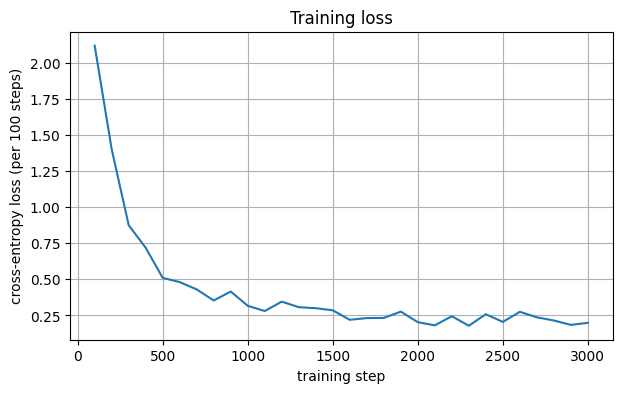

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(np.arange(1, len(loss_history)+1) * 100, loss_history)
plt.xlabel('training step')
plt.ylabel('cross-entropy loss (per 100 steps)')
plt.title('Training loss')
plt.grid(True)
plt.show()


## 11. Evaluation

We evaluate the trained network on the full 10000-image MNIST test set.

In [ ]:
def predict(image, params):
    y, _ = forward(image, params)
    return int(np.argmax(y))

n_correct = 0
N_TEST = Xte.shape[0]
for k in range(N_TEST):
    if predict(Xte[k][None,:,:], params) == Yte[k]:
        n_correct += 1
acc = n_correct / N_TEST
print(f"Test accuracy: {n_correct}/{N_TEST} = {100*acc:.2f}%")


Test accuracy: 9523/10000 = 95.23%


### Per-class accuracy and example predictions

In [ ]:
# Confusion matrix
conf = np.zeros((10,10), dtype=np.int64)
preds = np.zeros(N_TEST, dtype=np.int64)
for k in range(N_TEST):
    p = predict(Xte[k][None,:,:], params)
    preds[k] = p
    conf[Yte[k], p] += 1
print("Confusion matrix (rows = true label, columns = predicted):")
print(conf)
print()
for c in range(10):
    correct = conf[c, c]; total = conf[c].sum()
    print(f"  digit {c}: {correct}/{total} = {100*correct/total:.1f}%")


Confusion matrix (rows = true label, columns = predicted):
[[ 974    0    1    0    0    1    1    2    1    0]
 [   0 1116   10    3    0    0    3    0    3    0]
 [   5    1 1002    2    3    0    0   11    8    0]
 [   2    0   23  957    0   10    0   11    6    1]
 [   3    7   13    1  914    0    4    8    3   29]
 [  10    1    4   21    0  843    6    3    4    0]
 [  15    5    1    1    5    8  921    0    2    0]
 [   2    2   39    3    0    0    0  975    1    6]
 [  11    4   18   10    3    5    3   15  894   11]
 [   6    7    6   13    4    9    0   35    2  927]]

  digit 0: 974/980 = 99.4%
  digit 1: 1116/1135 = 98.3%
  digit 2: 1002/1032 = 97.1%
  digit 3: 957/1010 = 94.8%
  digit 4: 914/982 = 93.1%
  digit 5: 843/892 = 94.5%
  digit 6: 921/958 = 96.1%
  digit 7: 975/1028 = 94.8%
  digit 8: 894/974 = 91.8%
  digit 9: 927/1009 = 91.9%


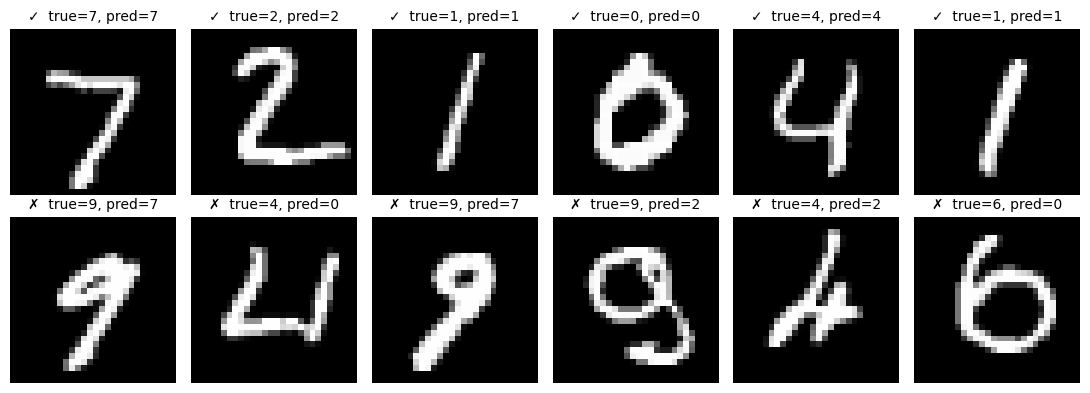

In [ ]:
# Show some correctly-classified and some mis-classified examples
correct_idx   = np.where(preds == Yte)[0][:6]
incorrect_idx = np.where(preds != Yte)[0][:6]

fig, ax = plt.subplots(2, 6, figsize=(11, 4))
for j, k in enumerate(correct_idx):
    ax[0,j].imshow(Xte[k], cmap='gray')
    ax[0,j].set_title(f'✓  true={Yte[k]}, pred={preds[k]}', fontsize=10)
    ax[0,j].axis('off')
for j, k in enumerate(incorrect_idx):
    ax[1,j].imshow(Xte[k], cmap='gray')
    ax[1,j].set_title(f'✗  true={Yte[k]}, pred={preds[k]}', fontsize=10)
    ax[1,j].axis('off')
plt.tight_layout()
plt.show()


## 12. What did the first convolution layer learn?

Here I visualise the 8 learned $3 \times 3$ filters from the first convolution layer. They are small, but they still show that the model has started to learn simple patterns from the MNIST images, such as edges, corners and changes in direction.

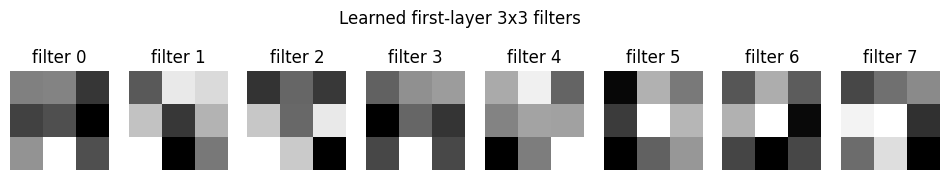

In [ ]:
W1 = params[0]   # (8, 1, 3, 3)
fig, ax = plt.subplots(1, 8, figsize=(12, 2))
for c in range(8):
    ax[c].imshow(W1[c, 0], cmap='gray')
    ax[c].set_title(f'filter {c}')
    ax[c].axis('off')
plt.suptitle('Learned first-layer 3x3 filters', y=1.05)
plt.show()


## 13. Brief Discussion

The gradient check showed that the manual backpropagation was working correctly, and the model reached a final test accuracy of **95.23%** on MNIST.

The model was kept simple because the main aim was to implement the CNN from scratch and understand each part of the pipeline. Training was slower because it was written mainly in NumPy and run on the CPU.

A fuller discussion of the results and limitations is included in the report.